In [2]:
# -*- coding: utf-8 -*-
from RegionMap import RegionMap
from Fleet import Monitoring_Fleet

import numpy as np
import pandas as pd
import os 
from datetime import datetime
import torch

In [3]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [ ]:
def run(link, df_link, File, id = 'pred_vdist', load = True):

    N_episodes = 1000
    ep_len     = 5
    
    buffer_size = 6000
    batch_size = 32
    
    # ----- Create a map -----
    
    x_size = 20
    y_size = 30

    list_of_small_pertb = [[0,4], [13,5], [17,25]]
    list_of_big_pert = [[6,9],[17,25]]
    
    Map = RegionMap(y_size, x_size, [], [], 1, df_link = df_link, link = link, listFileNumbers=File, load = load)
    Map.initialize_better_importance_map(id)
    
    # ----- Create a fleet -----
    
    drone_init_pos = [[5,5], [5,20], [18, 4], [19,21]]
      
    state_shape = [ep_len, 13]    
    alpha = 1e-4
    num_stacked = 2
    
    pretrained_folder = None    
 
    F = Monitoring_Fleet(Map, buffer_size, state_shape, pretrained_folder, lstm = False, gru = True, num_stacked = num_stacked, alpha = alpha) 
    F.add_drones(drone_init_pos)    
    
    #----- Create save folder paths -----
    
    np.set_printoptions(threshold=np.inf)
    
    current_folder = os.getcwd()
    save_folder = current_folder + "/Results"
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)    
        
    now = datetime.now()
    date_time = now.strftime("%m_%d_%Y_%H_%M_%S")    
    
    current_results = save_folder + "/" + date_time + "_pretraining_GRU"
    if not os.path.exists(current_results):
        os.makedirs(current_results)    
    
    #----- Simultaion pretraining -----
    
    load_data_link = '/Results_/11_20_2024_02_07_05'
    
    #F.pretrain(current_results, N_iter=100000, load_data=load_data_link, plot_pretrained=True)
    
    #----- Simulation Continue training -----

    # to train GRU
    pretrained_folder = None
    F.continue_training(current_results, lr=1e-4, n_lstm=2, N_iter=20000, load_data=load_data_link, pretrained_folder=pretrained_folder)


    torch.save(F.policy_network.state_dict(), "GRU_13_2_20000iter.pth") 
    
    
    # pretrained_folder= "/Results/11_20_2024_02_14_49_pretraining/Saved_models/policy_network_49999.pt"
    # F.continue_training(current_results, lr=1e-4, n_lstm=2, N_iter=20000, load_data=load_data_link, pretrained_folder=pretrained_folder, plot_pretrained=True)    
     

In [4]:
# Path to load the data

# Amélie
# link = r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# # Orane
link = r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg"
df_link = pd.read_csv(r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

Iteration: 199
Loss:  51.778690592447916
Iteration: 399
Loss:  50.28199462890625
Iteration: 599
Loss:  44.706396484375
Iteration: 799
Loss:  59.39822184244792


c:\Users\orane\Documents\GitHub\Projet-CE-1\REAL DATA\Fleet.py:595: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


Iteration: 999
Loss:  38.00225830078125
Iteration: 1199
Loss:  59.256551106770836
Iteration: 1399
Loss:  59.58918863932292
Iteration: 1599
Loss:  95.6486328125
Iteration: 1799
Loss:  64.1587646484375


c:\Users\orane\Documents\GitHub\Projet-CE-1\REAL DATA\Fleet.py:595: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


Iteration: 1999
Loss:  67.86020100911459
Iteration: 2199
Loss:  43.86296793619792
Iteration: 2399
Loss:  64.07294921875
Iteration: 2599
Loss:  51.668155924479166
Iteration: 2799
Loss:  53.6565185546875


...

c:\Users\orane\Documents\GitHub\Projet-CE-1\REAL DATA\Fleet.py:595: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


Iteration: 18999
Loss:  16.655103556315105
Iteration: 19199
Loss:  15.229122924804688
Iteration: 19399
Loss:  16.181791178385417
Iteration: 19599
Loss:  17.97471923828125
Iteration: 19799
Loss:  15.698687744140624


c:\Users\orane\Documents\GitHub\Projet-CE-1\REAL DATA\Fleet.py:595: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


Iteration: 19999
Loss:  14.219389851888021


c:\Users\orane\Documents\GitHub\Projet-CE-1\REAL DATA\Fleet.py:616: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


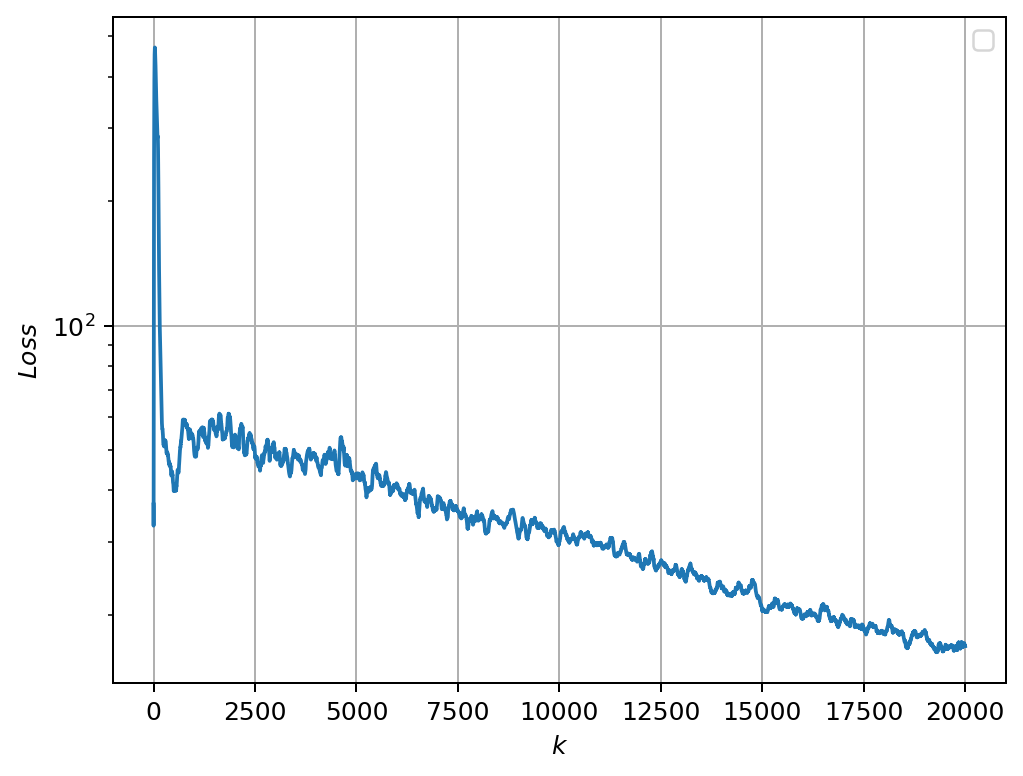

In [5]:
run(link, df_link, ['000'], id = 'pred_vdist', load = True)

In [5]:
path_loss = os.getcwd() + r'\Results\05_10_2025_16_16_02_pretraining_GRU\Saved_models\log_avg_losses.npy'
path_reward = os.getcwd() + r'\Results\05_10_2025_16_16_02_pretraining_GRU\Saved_models\log_average_score.npy'

losses_npy = np.load(path_loss)
reward_npy = np.load(path_reward)

losses = np.array(losses_npy, dtype=np.float32)
rewards = np.array(reward_npy, dtype=np.float32)

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\orane\\Documents\\GitHub\\Projet-CE-1\\REAL DATA\\Results\\05_10_2025_16_16_02_pretraining_GRU\\Saved_models\\log_avg_losses.npy'